# AffectNet Test-Time Augmentation (TTA) on Kaggle

This notebook is designed to perform Test-Time Augmentation (TTA) on the AffectNet dataset using a pre-trained Vision Transformer-based model. TTA can improve model performance by averaging predictions over multiple augmented versions of an input image.

### Steps:
1.  **Setup**: Import libraries and define necessary classes/functions.
2.  **Configuration**: Set up paths for the dataset and the pre-trained model checkpoint. This is important for running on Kaggle.
3.  **Load Data & Model**: Load the AffectNet validation set and the trained `FERClassifier` model.
4.  **Define Augmentations**: Specify the set of transformations to be used for TTA.
5.  **Evaluate**: 
    *   Run a standard evaluation as a baseline.
    *   Run evaluation with TTA.
    *   Compare the results.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import timm
import os
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import copy
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


## 1. Helper Functions and Class Definitions

Here we define the necessary classes and functions for the dataset and the model, adapted from the original training notebook.


In [2]:
class PatchedAttention(timm.models.vision_transformer.Attention):
    """
    A patched version of the timm Attention to return attention weights.
    """
    def forward(self, x, return_attention=False):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn_to_return = attn # Save before dropout
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        if return_attention:
            return x, attn_to_return
        return x



In [3]:
class AffectNetClassificationDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, transform=None):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.transform = transform
        self.annotations = {}
        annotation_files = [file for file in os.listdir(annotation_dir) if file.endswith('.npy')]
        for file in tqdm(annotation_files, desc="Loading AffectNet annotation files"):
            key = file.split('.')[0]
            npy_path = os.path.join(annotation_dir, file)
            self.annotations[key] = np.load(npy_path, allow_pickle=True)
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        img_id = os.path.splitext(img_name)[0]
        aro = self.annotations.get(f'{img_id}_aro', np.array([-1]))
        val = self.annotations.get(f'{img_id}_val', np.array([-1]))
        exp = self.annotations.get(f'{img_id}_exp', np.array([-1]))
        aro = aro.item() if aro.size == 1 else aro
        val = val.item() if val.size == 1 else val
        exp = exp.item() if exp.size == 1 else exp
        labels = {
            'arousal': aro,
            'valence': val,
            'expression': exp
        }
        return image, labels

def create_mae_model_from_timm(new_depth=6):
    # Step 1: Create ViT encoder with same architecture, without downloading
    encoder = timm.create_model(
        'vit_base_patch16_224',
        pretrained=False,  # Prevents downloading
        img_size=224,
        patch_size=16,
        embed_dim=768,
        depth=new_depth,
        num_heads=12,
        mlp_ratio=4.0
    )

    # Step 2: Load local checkpoint (make sure it's compatible with your encoder config)
    ckpt_path = '../models/vit_base_patch16_224.pth'
    state_dict = torch.load(ckpt_path, map_location='cpu')
    
    # If needed, remove "module." prefix (some checkpoints have it)
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # Load weights
    missing_keys, unexpected_keys = encoder.load_state_dict(state_dict, strict=False)
    print("✅ Loaded encoder weights.")
    print(f"Missing keys: {len(missing_keys)} | Unexpected keys: {len(unexpected_keys)}")

    return encoder


class SimpleMAE(torch.nn.Module):
    def __init__(
        self, 
        encoder,
        decoder_embed_dim=512,
        decoder_depth=8,
        decoder_num_heads=16,
        mask_ratio=0.75,
        norm_pix_loss=True
    ):
        super().__init__()
        self.encoder = encoder
        self.img_size = encoder.patch_embed.img_size[0]
        self.patch_size = encoder.patch_embed.patch_size[0]
        self.embed_dim = encoder.embed_dim
        self.num_patches = (self.img_size // self.patch_size) ** 2
        self.mask_token = torch.nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_embed = torch.nn.Linear(self.embed_dim, decoder_embed_dim, bias=True)
        self.decoder_pos_embed = torch.nn.Parameter(torch.zeros(1, self.num_patches + 1, decoder_embed_dim))
        self.decoder_blocks = torch.nn.ModuleList([
            timm.models.vision_transformer.Block(
                decoder_embed_dim, decoder_num_heads, 4.0
            ) for _ in range(decoder_depth)
        ])
        
        self.decoder_norm = torch.nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = torch.nn.Linear(
            decoder_embed_dim, self.patch_size**2 * 3, bias=True
        )
        
        self.mask_ratio = mask_ratio
        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights()
    
    def initialize_weights(self):
        torch.nn.init.normal_(self.mask_token, std=0.02)
        torch.nn.init.normal_(self.decoder_pos_embed, std=0.02)
        torch.nn.init.xavier_uniform_(self.decoder_embed.weight)
        torch.nn.init.zeros_(self.decoder_embed.bias)
        torch.nn.init.xavier_uniform_(self.decoder_pred.weight)
        torch.nn.init.zeros_(self.decoder_pred.bias)
    
    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(
            x, dim=1, 
            index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
        )
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward_encoder(self, x, mask_ratio):
        patches = self.encoder.patch_embed(x)
        patches = patches + self.encoder.pos_embed[:, 1:, :]
        patches_masked, mask, ids_restore = self.random_masking(patches, mask_ratio)
        cls_token = self.encoder.cls_token + self.encoder.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(patches_masked.shape[0], -1, -1)
        x = torch.cat((cls_tokens, patches_masked), dim=1)
        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)
        
        return x, mask, ids_restore
    
    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(
            x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1
        )
        x_ = x[:, 1:, :]
        x_ = torch.cat([x_, mask_tokens], dim=1)
        x_ = torch.gather(
            x_, dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2])
        )
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)
        x = self.decoder_pred(x)
        x = x[:, 1:, :]
        
        return x
    
    def patchify(self, imgs):
        p = self.patch_size
        h = w = self.img_size // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
        
        return x
    
    def unpatchify(self, x):
        p = self.patch_size
        h = w = int(x.shape[1]**0.5)
        assert h * w == x.shape[1]
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, w * p))
        
        return imgs
    
    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**0.5
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        
        return loss
    
    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is None:
            mask_ratio = self.mask_ratio
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask, ids_restore

class FERClassifier(nn.Module):
    """
    Facial Expression Recognition Classifier.
    This model uses a pre-trained MAE encoder (a ViT) as a backbone
    and adds a simple linear classifier on top of the [CLS] token embedding.
    """
    def __init__(self, mae_encoder, num_classes=7):
        super().__init__()
        self.encoder = mae_encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(mae_encoder.embed_dim),
            nn.Linear(mae_encoder.embed_dim, num_classes)
        )

    def forward(self, x, return_attention=False):
        # Pass input through the ViT encoder
        tokens = self.encoder.patch_embed(x)
        cls_token = self.encoder.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_token, tokens), dim=1)
        x = x + self.encoder.pos_embed[:, :x.size(1), :]
        x = self.encoder.pos_drop(x)

        attn_maps = []
        for blk in self.encoder.blocks:
            if return_attention:
                # Manually implement the forward pass of the block to get attention
                residual = x
                attn_output, attn_weights = blk.attn(blk.norm1(x), return_attention=True)
                x = residual + attn_output

                residual = x
                mlp_output = blk.mlp(blk.norm2(x))
                x = residual + mlp_output
                
                attn_maps.append(attn_weights)
            else:
                x = blk(x)

        x = self.encoder.norm(x)
        
        # Get the [CLS] token embedding
        cls_embedding = x[:, 0]

        # Pass the [CLS] token through the classifier head
        logits = self.classifier(cls_embedding)

        if return_attention:
            return logits, attn_maps
        else:
            return logits


## 2. Configuration

Set the paths for your dataset and model. When running on Kaggle, these paths will typically start with `/kaggle/input/`.


In [4]:
# --- Configuration ---
# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# TODO: Update these paths for your Kaggle environment
# Path to the pre-saved PyTorch dataset file
VAL_DATASET_PT_PATH = '../datasets/AffectNet/AffectNet-torch/test_dataset.pt' # Example: '/kaggle/input/affectnet-pt/test_dataset.pt'

# The .pt file likely has an old image path, so we set the correct one here.
VAL_IMAGE_DIR = '../datasets/AffectNet/AffectNet-images/val_set/images' # Example: '/kaggle/input/affectnet-images/val_set/images'

# Path to the model checkpoint
MODEL_CHECKPOINT_PATH = '../checkouts/fer_test/fer_model_epoch_19.pth' # Example: '/kaggle/input/affectnet-models/fer_model_epoch_19.pth'

# Model parameters
NUM_CLASSES = 7  # For AffectNet without 'Contempt'
ENCODER_DEPTH = 6
BATCH_SIZE = 64


Using device: cuda


## 3. Define TTA Transformations

We define the standard validation transform and a set of TTA transforms. The TTA transforms will create multiple augmented versions of each validation image. We will use horizontal flips and five different crops (center + four corners).


In [5]:
# --- Transformations ---

# Standard validation transform (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Test-Time Augmentation transforms
tta_transforms = [
    # Original
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ]),
    # Horizontal Flip
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ]),
    # 2. Flipped Original
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ]),
    # 3. Center Crop
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ]),
    # 4. Flipped Center Crop
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(288), # Start with a larger image
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    # 6. Flipped Larger-Scale Center Crop
    transforms.Compose([
        transforms.Resize(288),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    # 7. Rotation
    transforms.Compose([
        transforms.RandomRotation(7),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    # 8. Flipped Rotation
    transforms.Compose([
        transforms.RandomRotation(7),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
]


## 4. Load Data and Model

Here, we instantiate the dataset and the model, and then load the pre-trained weights from the checkpoint file.


In [6]:
# --- Load Dataset ---
try:
    # Load the pre-saved dataset object, allowing it to unpickle the class
    val_data = torch.load(VAL_DATASET_PT_PATH, map_location='cpu', weights_only=False)
    
    # IMPORTANT: Update the image directory path to match the Kaggle environment
    val_data.image_dir = VAL_IMAGE_DIR
    
    # 1. Prepare dataset for standard evaluation
    val_dataset_std = val_data
    val_dataset_std.transform = val_transform
    val_loader_std = DataLoader(val_dataset_std, batch_size=BATCH_SIZE, shuffle=False)
    
    # 2. Prepare dataset for TTA evaluation
    val_dataset_tta = copy.deepcopy(val_data)
    val_dataset_tta.transform = None # TTA transforms are applied manually
    
    print(f"Successfully loaded and prepared {len(val_dataset_std)} images for validation.")

except FileNotFoundError:
    print(f"🚨 Dataset file not found at {VAL_DATASET_PT_PATH}. Please check the path in the 'Configuration' section.")
    # Create dummy loaders to prevent NameError later
    val_loader_std = []
    val_dataset_tta = []
except Exception as e:
    print(f"🚨 An error occurred while loading the dataset: {e}")
    val_loader_std = []
    val_dataset_tta = []


# --- Load Model ---
try:
    # 1. Create the MAE encoder backbone
    mae_encoder = create_mae_model_from_timm(new_depth=ENCODER_DEPTH)

    # 2. Create the final classifier
    model = FERClassifier(mae_encoder=mae_encoder, num_classes=NUM_CLASSES)

    # 3. Load the checkpoint
    print(f"Loading model from: {MODEL_CHECKPOINT_PATH}")
    checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE)
    
    # Check if weights are in a 'model_state_dict' key or in the root of the checkpoint
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
        
    print("✅ Model weights loaded successfully.")

    # 4. Move model to device and set to evaluation mode
    model.to(DEVICE)
    model.eval()

except FileNotFoundError:
    print(f"🚨 Model checkpoint not found at {MODEL_CHECKPOINT_PATH}. Please check the path.")
except Exception as e:
    print(f"🚨 An error occurred while loading the model: {e}")


Successfully loaded and prepared 3999 images for validation.
✅ Loaded encoder weights.
Missing keys: 0 | Unexpected keys: 72
Loading model from: ../checkouts/fer_test/fer_model_epoch_19.pth
✅ Model weights loaded successfully.


In [7]:
# Monkey-patch FERClassifier.forward to compute attention weights manually
import types as _types

def _fer_forward_with_attention(self, x, return_attention=False):
    # Pass input through the ViT encoder
    tokens = self.encoder.patch_embed(x)
    cls_token = self.encoder.cls_token.expand(x.size(0), -1, -1)
    x = torch.cat((cls_token, tokens), dim=1)
    x = x + self.encoder.pos_embed[:, :x.size(1), :]
    x = self.encoder.pos_drop(x)

    attn_maps = []
    for blk in self.encoder.blocks:
        if return_attention:
            norm1_x = blk.norm1(x)
            B, N, C = norm1_x.shape
            qkv = blk.attn.qkv(norm1_x).reshape(B, N, 3, blk.attn.num_heads, C // blk.attn.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * blk.attn.scale
            attn = attn.softmax(dim=-1)
            attn_weights = attn

            attn_output = blk.attn(norm1_x)  # call without unsupported kwargs
            x = x + attn_output

            mlp_output = blk.mlp(blk.norm2(x))
            x = x + mlp_output

            attn_maps.append(attn_weights)
        else:
            x = blk(x)

    x = self.encoder.norm(x)
    cls_embedding = x[:, 0]
    logits = self.classifier(cls_embedding)

    if return_attention:
        return logits, attn_maps
    else:
        return logits

# Bind to existing model instance if available
try:
    if 'model' in globals():
        model.forward = _types.MethodType(_fer_forward_with_attention, model)
except Exception as _e:
    print(f"Warning: could not monkey-patch FERClassifier.forward: {_e}")


## 5. Evaluation Functions

We'll define two functions:
1.  `evaluate_standard`: A straightforward evaluation on the validation set using the standard, non-augmented data. This serves as our baseline.
2.  `evaluate_tta`: Performs Test-Time Augmentation. For each image, it generates multiple augmented versions, gets predictions for each, and then averages these predictions to get a final, potentially more robust, result.


In [8]:
def evaluate_standard(model, data_loader):
    """
    Performs a standard evaluation on the validation dataset.
    """
    model.eval()
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_dict in tqdm(data_loader, desc="Standard Evaluation"):
            # Extract expression labels from the dictionary
            labels = torch.tensor([int(x) for x in labels_dict['expression']], dtype=torch.long)

            # Filter out invalid labels (-1)
            valid_mask = (labels >= 0) & (labels < NUM_CLASSES)
            if valid_mask.sum() == 0:
                continue

            images = images[valid_mask].to(DEVICE)
            labels = labels[valid_mask].to(DEVICE)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"Standard Accuracy: {accuracy:.2f}%")
    return accuracy, all_labels, all_preds


In [9]:
def evaluate_tta(model, dataset, tta_transforms):
    """
    Performs Test-Time Augmentation evaluation.
    """
    model.eval()
    correct = 0
    total = 0
    
    all_preds_tta = []
    all_labels_tta = []

    for i in tqdm(range(len(dataset)), desc="TTA Evaluation"):
        # Get original image and label dictionary
        original_image, labels_dict = dataset[i]
        label = int(labels_dict['expression'])
        
        # Skip invalid labels
        if not (0 <= label < NUM_CLASSES):
            continue

        # Store predictions from all augmented versions
        tta_predictions = []

        with torch.no_grad():
            for transform in tta_transforms:
                augmented_image = transform(original_image)
                
                if augmented_image.dim() == 3:
                    augmented_image = augmented_image.unsqueeze(0)
                
                outputs = model(augmented_image.to(DEVICE))
                
                # Use softmax to get probabilities
                probabilities = F.softmax(outputs, dim=1)
                
                # Average probabilities if it was a FiveCrop
                if probabilities.shape[0] > 1:
                    probabilities = probabilities.mean(0, keepdim=True)

                tta_predictions.append(probabilities)

            # Average the predictions from all transforms
            avg_probabilities = torch.mean(torch.cat(tta_predictions, dim=0), dim=0)
            _, final_prediction = torch.max(avg_probabilities, 0)
            
            total += 1
            if final_prediction.item() == label:
                correct += 1
                
            all_preds_tta.append(final_prediction.item())
            all_labels_tta.append(label)

    accuracy = 100 * correct / total
    print(f"TTA Accuracy: {accuracy:.2f}%")
    return accuracy, all_labels_tta, all_preds_tta


## 6. Run Evaluation and Compare Results

Finally, we execute both the standard and TTA evaluation functions and print the results to compare them. We also define the class names for AffectNet to aid in interpreting a confusion matrix if desired.


## 7. Quantitative Results (Precision, Recall, F1-score)

In this section, we'll compute and display detailed classification metrics for both the standard and TTA evaluation methods. This will help us understand the model's performance beyond simple accuracy, looking at how well it performs on each specific emotion class.



In [10]:
# AffectNet 7-class mapping (as used in training)
class_names = [
    "Neutral", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Anger"
]

# --- Run Standard Evaluation ---
try:
    std_accuracy, std_labels, std_preds = evaluate_standard(model, val_loader_std)
except Exception as e:
    print(f"Could not run standard evaluation. Please check your paths in the 'Configuration' section.")
    print(f"Error: {e}")
    std_accuracy, std_labels, std_preds = "N/A", [], []


# --- Run TTA Evaluation ---
try:
    tta_accuracy, tta_labels, tta_preds = evaluate_tta(model, val_dataset_tta, tta_transforms)
except Exception as e:
    print(f"Could not run TTA evaluation. Please check your paths in the 'Configuration' section.")
    print(f"Error: {e}")
    tta_accuracy, tta_labels, tta_preds = "N/A", [], []

# --- Final Comparison ---
print("\n--- Evaluation Summary ---")
print(f"Standard Accuracy: {std_accuracy}")
print(f"TTA Accuracy:      {tta_accuracy}")
print("--------------------------")


Standard Evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:11<00:00,  5.26it/s]


Standard Accuracy: 56.94%


TTA Evaluation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3999/3999 [01:57<00:00, 34.12it/s]

TTA Accuracy: 57.20%

--- Evaluation Summary ---
Standard Accuracy: 56.94285714285714
TTA Accuracy:      57.2
--------------------------


In [11]:
# --- Classification Reports ---
print("--- Standard Evaluation Classification Report ---")
if std_labels and std_preds:
    print(classification_report(std_labels, std_preds, target_names=class_names))
else:
    print("Could not generate report due to evaluation error.")

print("\\n--- TTA Evaluation Classification Report ---")
if tta_labels and tta_preds:
    print(classification_report(tta_labels, tta_preds, target_names=class_names))
else:
    print("Could not generate report due to evaluation error.")



--- Standard Evaluation Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.38      0.81      0.52       500
       Happy       0.65      0.94      0.77       500
         Sad       0.60      0.59      0.59       500
    Surprise       0.60      0.46      0.52       500
        Fear       0.82      0.42      0.55       500
     Disgust       0.87      0.25      0.39       500
       Anger       0.59      0.53      0.56       500

    accuracy                           0.57      3500
   macro avg       0.64      0.57      0.56      3500
weighted avg       0.64      0.57      0.56      3500

\n--- TTA Evaluation Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.39      0.80      0.52       500
       Happy       0.66      0.94      0.77       500
         Sad       0.60      0.62      0.61       500
    Surprise       0.59      0.46      0.51       500
        Fear       0.79      0.40  

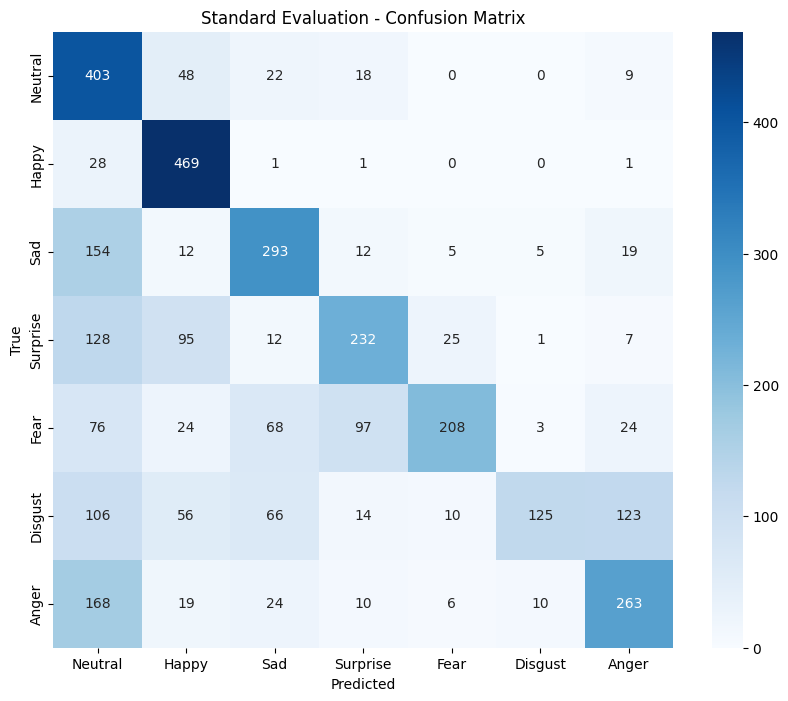

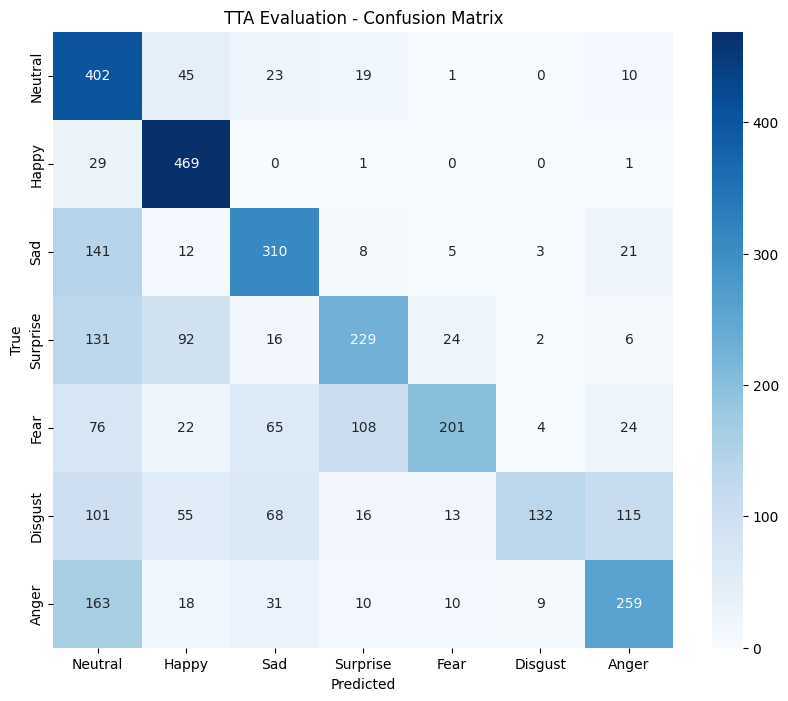

In [12]:
# --- Confusion Matrices ---
def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

if std_labels and std_preds:
    plot_confusion_matrix(std_labels, std_preds, class_names, 'Standard Evaluation - Confusion Matrix')

if tta_labels and tta_preds:
    plot_confusion_matrix(tta_labels, tta_preds, class_names, 'TTA Evaluation - Confusion Matrix')



## 8. Qualitative Results (Attention Map Visualization)

In this section, we'll visualize the attention maps from the Vision Transformer to understand what parts of the input image the model is focusing on when making a prediction. This provides insight into the model's decision-making process.



Example 1: True Label: Neutral


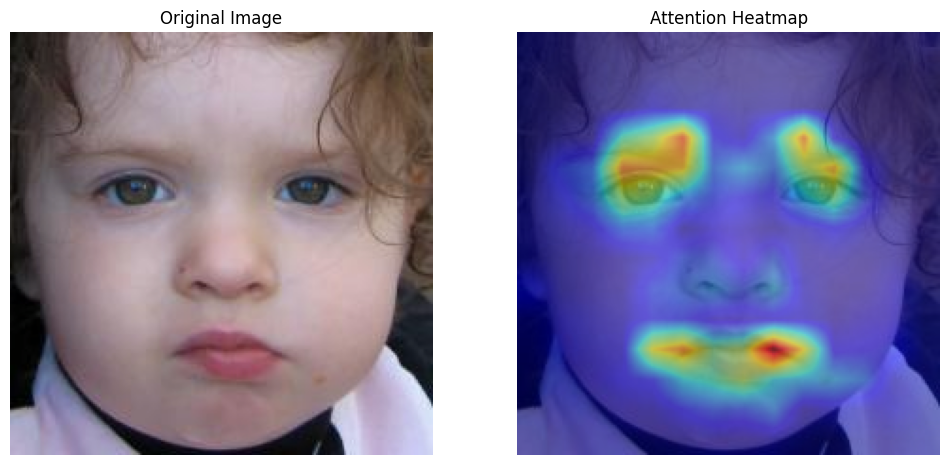

Example 2: True Label: Fear


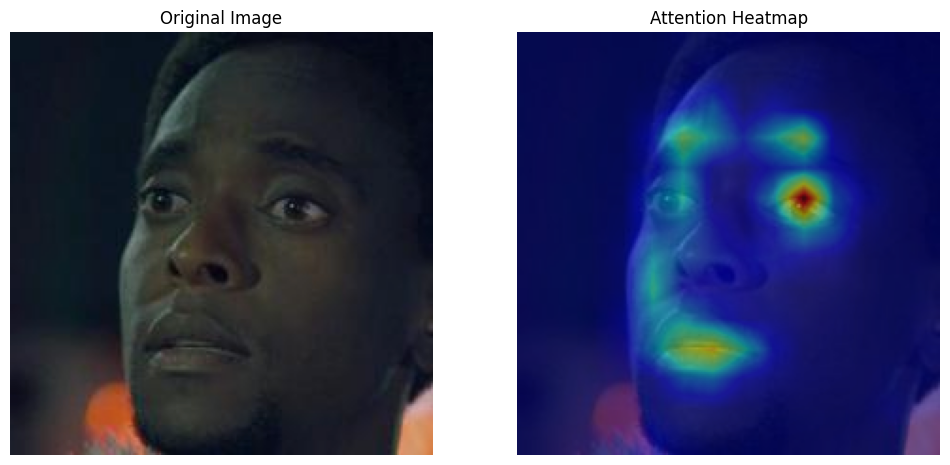

Example 3: True Label: Sad


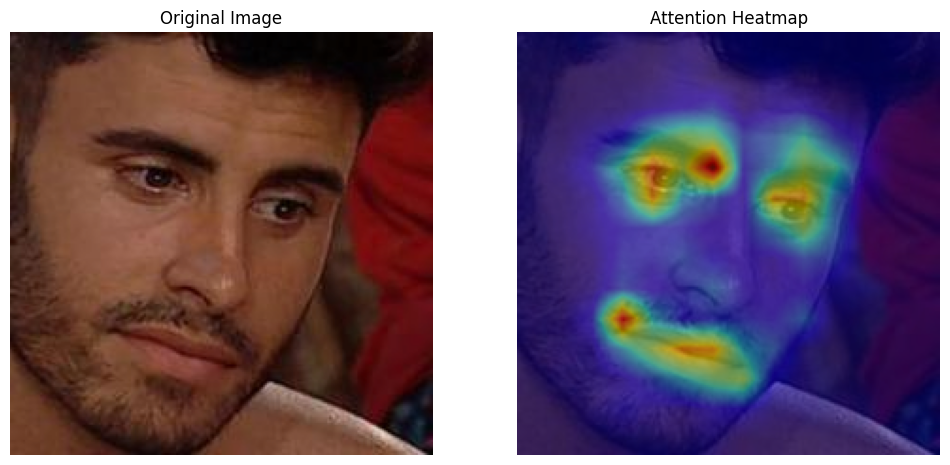

In [13]:
def visualize_attention(model, image, transform, device):
    """
    Visualizes the attention map for a given image.
    """
    # Preprocess the image
    img_tensor = transform(image).unsqueeze(0).to(device)

    # Get model predictions and attention maps
    logits, attn_maps = model(img_tensor, return_attention=True)
    
    # We are interested in the attention from the [CLS] token in the last layer
    # Shape: (batch_size, num_heads, num_tokens, num_tokens)
    last_layer_attn = attn_maps[-1].squeeze(0)  # Remove batch dim
    
    # Average attention across all heads for the [CLS] token
    cls_attn = last_layer_attn[:, 0, 1:].mean(dim=0) # Avg over heads, select CLS token, remove CLS token from sequence

    # Reshape to a 2D grid
    num_patches = 14 # 224x224 image with 16x16 patches -> 14x14 patches
    attn_grid = cls_attn.reshape(num_patches, num_patches).cpu().detach().numpy()

    # Resize to original image size
    attn_resized = torch.nn.functional.interpolate(
        torch.tensor(attn_grid).unsqueeze(0).unsqueeze(0),
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    ).squeeze().numpy()

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original Image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title("Original Image")

    # Attention Map
    ax2.imshow(image)
    ax2.imshow(attn_resized, alpha=0.5, cmap='jet')
    ax2.axis('off')
    ax2.set_title("Attention Heatmap")

    plt.show()

# --- Display a few examples ---
num_examples = 3
for i in range(num_examples):
    # Get an image from the validation set
    img, label_dict = val_dataset_std[i*100] # Pick some spaced out images
    
    # The dataset returns a tensor, convert it back to PIL for visualization
    # We need to un-normalize it first
    un_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_for_viz = un_normalize(img)
    img_for_viz = transforms.ToPILImage()(img_for_viz)

    print(f"Example {i+1}: True Label: {class_names[int(label_dict['expression'])]}")
    
    # Create a transform for this single image (without normalization for model input)
    viz_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    visualize_attention(model, img_for_viz, viz_transform, DEVICE)

